# **Assignment 3: Introduction to Deep Learning for Sound Event Classification**
### Due: Thursday, March 12th, midnight EST
### Quiz date: Tuesday, March 17th in-class

CS-GY 6933: Machine Listening Spring 2026

Below you will find a mix of coding questions and writing questions to familiarize you with the fundamentals of signal processing in Python.

The assignment will have two parts:

1. Part 0: **Tutorial**: getting used to working with PyTorch (tensors, data loading, training and evaluating a simple model). This portion is not worth any points and typically will not have anything to "fill-in". I recommend you walk through the code and run it to understand the pieces before moving on if you are new to this material.

2. Parts 1-3: **Problem solving**: MFCC feature design (2pts), and model design for sound event classification (3pts). Totaling 5 points. The in-class quiz about the assignment will also be worth 5 points. There is also 1 point of extra credit available in this section!⭐


**A note on GPU Colab credits:** we can get a free student Pro membership to Colab that has 100 compute credits per month. Using an L4 GPU will get you plenty fast performance for these experiments and only uses 1.71 credits per hour (though don't turn to GPU runtime until the model training to save credits).


When you complete the assignment, please evaluate the notebook so that all results are shown/printed before submitting via Brightspace.



🚨 Please refrain from using ChatGPT etc. to fully write the code for this assignment. You will need to understand the content to succeed in the in-class quiz.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from tqdm import tqdm

In [2]:
!pip install torchinfo

In [3]:
from torchinfo import summary

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# Our simple dataset class
class SimpleDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data  # (ex: numpy array of (n_samples, n_features), list of filepaths etc.)
        self.labels = labels  # (ex: list of class labels)

        print(f'Number of data samples: {len(self.data)}')

    def __len__(self):
        return len(self.data)  # Return dataset size, this is just a formality

    # Get item is the core method that retrieves one sample (and a label, optionally)
    def __getitem__(self, idx):
        # idx is the index into your full dataset (e.g. sample at index 2 from your dataset)
        return self.data[idx], self.labels[idx]  # Return sample and label


In [ ]:

# Our simple dataset class
class ESC50Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = data  # (ex: numpy array of (n_samples, n_features), list of filepaths etc.)
        self.labels = labels  # (ex: list of class labels)

        print(f'Number of data samples: {len(self.data)}')

    def __len__(self):
        return len(self.data)  # Return dataset size, this is just a formality

    # Get item is the core method that retrieves one sample (and a label, optionally)
    def __getitem__(self, idx):
        # idx is the index into your full dataset (e.g. sample at index 2 from your dataset)
        return self.data[idx], self.labels[idx]  # Return sample and label


### Model definition
Below we define a simple single-layer model class in PyTorch. Read through the comments to understandn the __init__ and forward() functionalities. Note that the weights and biases of your model layers are "under the hood" below - we won't be explicitly defining them here.

In [ ]:
class SimpleModel(nn.Module):
    def __init__(self, input_channels, n_classes):
        super(SimpleModel, self).__init__() # formality
        # Here we define the model architecture
        # This *doesn't* tell us how data flows through the model, just the architecture

        # Define one single linear layer
        # This has to accept 2-dim input and return n_classes output
        # Input should be (batch_size, input_channels)
        # Linear layer operates on channel dimension only
        self.fc = nn.Linear(input_channels, n_classes)

    # The forward pass is the core method in a model class
    # This determines how data x flows through the network
    def forward(self, x):
        output = self.fc(x)
        return output

In [4]:
# Simple function to get the model config and number of parameters
def print_model(model):
    # Print model's state_dict
    print("Model's state dictionary (stored weights):")
    for param_tensor in model.state_dict():
        print("  ", param_tensor, "\t", tuple(model.state_dict()[param_tensor].size()))

    # Print the number of parameters in the model
    parameter_count =  sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("In total, this network has ", parameter_count, " trainable parameters")


In [ ]:
print_model(SimpleModel(input_channels=2, n_classes=10))

Model's state dictionary (stored weights):
   fc.weight 	 (10, 2)
   fc.bias 	 (10,)
In total, this network has  30  trainable parameters


In [ ]:
# Let's test out passing some dummy data through the model
# This is only a *forward* pass through the model e.g. "inference" - not training or doing any back propogation
model = SimpleModel(input_channels=2, n_classes=5)
sample_data = torch.randn(10,2)
output = model(sample_data)
print(output.shape)

torch.Size([10, 5])


### Backpropogation and optimization in pytorch
In neural networks, the model will learn to map inputs through intermediate ("hidden") representations of varying dimensions. This complexity helps our model learn more complex mapping functions, but adds a level of difficulty in figuring out how to update the weights of all of our parameters of the model (e.g. with gradient descent!).

To update our network given a target and predicted output, we will compute the loss (e.g. mean-squared error) using a differentiable loss function, and then compute the gradient of the loss function with respect to each model weight, and performing a small update in the opposite direction of the gradient. The computation of these gradients is called backpropagation, and allows us to systematically train large and complex neural networks.

Luckily, PyTorch provides automatic differentiation (e.g. autograd), which provides a built-in gradient computation for us! Let's play with a few aspects of gradients in PyTorch before incorporating the model component.

In [ ]:
# Note that below, we aren't actually doing any "model training"
# This shows how we would do manual optimization - without using built-in optimization yet.

# Sample tensor
x = torch.ones(5)
print(f"Creating a tensor of type {type(x)} with shape {x.shape}")
print(f"Starting x: {x}")

# During backpropagation, gradients will only be computed for tensors with the
# `requires_grad` attribute set to True. We can set this manually if need be
print(f"Does our tensor require gradient computation? {x.requires_grad}")
x.requires_grad = True
print(f"Does our tensor require gradient computation? {x.requires_grad}")

# To perform backpropagation, we need to complete a "forward pass" in which
# computations are performed on Tensor objects to compute a scalar loss value
# This is just a dummy scalar loss function - in practice this will
loss = 10 - x.sum()
print(f"Starting `loss` value: {loss}")
print(f"Gradients of x: {x.grad}") # no gradients yet
print(f"Loss function requires_grad?: {loss.requires_grad}")

# PyTorch will compute all required gradients for tensors involved in the
# computation of a scalar loss value once we call `.backward()`
loss.backward()
print(f"Gradients of x: {x.grad}")

# We can manually update our `weights` in the opposite direction of this gradient
# to reduce our loss value!
x = x - x.grad
print(f"Updated x: {x.data}")
loss = 10 - x.sum()
print(f"Updated `loss` value: {loss}")

Creating a tensor of type <class 'torch.Tensor'> with shape torch.Size([5])
Starting x: tensor([1., 1., 1., 1., 1.])
Does our tensor require gradient computation? False
Does our tensor require gradient computation? True
Starting `loss` value: 5.0
Gradients of x: None
Loss function requires_grad?: True
Gradients of x: tensor([-1., -1., -1., -1., -1.])
Updated x: tensor([2., 2., 2., 2., 2.])
Updated `loss` value: 0.0


n the above example we computed differentiable a scalar loss, used backpropagation to compute the gradients of the loss with respect to our "weights," and performed a gradient-based update on our weights to reduce the loss. Rather than managing the weight-update process by hand, we can defer to a built-in optimizer object that automatically adjusts weights based on stored gradients and standard hyperparameters (e.g. learning rate). When training neural networks with large numbers of parameters, this becomes much simpler than manually updating each weight. ([Credit](https://github.com/interactiveaudiolab/course-deep-learning/blob/main/notebooks/notebook_2_nn.ipynb))

In [ ]:
# Repeat our simple optimization, this time using the optimizer.
x = torch.ones(5).requires_grad_(True)
print(f"Starting x: {x}")

# Create an optimizer object and pass it an Iterable containing our "weights".
# Here, SGD is the torch stochastic gradient descent optimizer.
# It has been handed our tensor x as something to optimize and the learning rate
# (lr) is set to 1, which determines the step size for making changes to x.
# Note that this example learning rate is very high! in practice we usuallyuse something like 0.1 or 0.01.
opt = torch.optim.SGD([x], lr = 1.0)

# Compute loss and perform backpropagation.
loss = 10 - x.sum()
loss.backward()

# perform an automatic optimization step, i.e. a gradient-based update of our weights
opt.step()

print(f"Updated x: {x}")

Starting x: tensor([1., 1., 1., 1., 1.], requires_grad=True)
Updated x: tensor([2., 2., 2., 2., 2.], requires_grad=True)


### Simple training pipeline
Finally, let's put all of the pieces together and write a simple training script for a dummy classification task.

In [ ]:
# Data setup
train_data = torch.randn(100, 10, dtype=torch.float32)  # 100 samples, each with 10 features
train_labels = torch.randint(0, 5, (100,))  # 100 labels between 0-4

# Create dataset and DataLoader
train_dataset = SimpleDataset(train_data, train_labels)

# Dataloader is an iterable wrapper class for dataset
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Also create the validation dataloader
val_data = torch.randn(20, 10, dtype=torch.float32)
val_labels = torch.randint(0, 5, (20,))
val_dataset = SimpleDataset(val_data, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Model setup
model = SimpleModel(input_channels=10, n_classes=5)

# Optimizer setup, on all of our model parameters
opt = torch.optim.SGD(model.parameters(), lr = 0.01)

# Define the loss function
loss_fn = nn.CrossEntropyLoss().to(device)





# TRAINING LOOP

# Loop through the entire [training] data each "epoch"
# So you will go through every "batch" of data inside this epoch
epochs = 10
for epoch in range(epochs):
    # This tells your model that you are in training mode and not testing mode
    # For our simple case this doesn't do much, but more complex layers such as Dropout
    # behave differently in training vs. evaluation mode
    model.train()
    total_loss = 0.0
    for batch in train_dataloader:
        inputs, targets = batch
        # Set the gradients to 0 before running the network on the data each iteration, so that
        # loss gradients can be computed correctly during backpropagation
        opt.zero_grad()
        # print(f"Model input shape (batch): {inputs.shape}")

        # Get the output of the network on the data
        # Note that these are probabilities, *not* class labels!
        output = model(inputs)
        # print(f"Model output shape (batch): {output.shape}")

        # Measure the "loss" using mean squared error
        loss = loss_fn(output, targets)

        # This calculates the gradients, performing backpropagation to propagate
        # errors backward through the network's weights
        loss.backward()

        # This updates the network weights based on the freshly-computed gradient
        # now stored alongside each weight
        opt.step()

        # Accumulate the total loss per epoch
        total_loss += loss.item()

    print(f"Training Epoch {epoch+1}/{epochs}, Train Loss: {total_loss / len(dataloader):.4f}")

    # VALIDATION LOOP
    # The validation loop
    model.eval()
    total_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # Disable gradient computation
        for batch in val_dataloader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_val_loss += loss.item()

            # Compute validation accuracy
            _, predicted = torch.max(outputs, dim=1)
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = correct_val / total_val

    # Print results
    print(f"Validation Epoch {epoch+1}/{epochs}, Val: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}\n")


Number of data samples: 100
Number of data samples: 20
Training Epoch 1/10, Train Loss: 1.7499
Validation Epoch 1/10, Val: 1.6842, Val Accuracy: 0.2000

Training Epoch 2/10, Train Loss: 1.7191
Validation Epoch 2/10, Val: 1.6733, Val Accuracy: 0.2500

Training Epoch 3/10, Train Loss: 1.6898
Validation Epoch 3/10, Val: 1.6642, Val Accuracy: 0.2000

Training Epoch 4/10, Train Loss: 1.6662
Validation Epoch 4/10, Val: 1.6565, Val Accuracy: 0.2000

Training Epoch 5/10, Train Loss: 1.6438
Validation Epoch 5/10, Val: 1.6506, Val Accuracy: 0.2000

Training Epoch 6/10, Train Loss: 1.6235
Validation Epoch 6/10, Val: 1.6456, Val Accuracy: 0.2000

Training Epoch 7/10, Train Loss: 1.6056
Validation Epoch 7/10, Val: 1.6418, Val Accuracy: 0.2500

Training Epoch 8/10, Train Loss: 1.5891
Validation Epoch 8/10, Val: 1.6393, Val Accuracy: 0.2500

Training Epoch 9/10, Train Loss: 1.5747
Validation Epoch 9/10, Val: 1.6373, Val Accuracy: 0.3000

Training Epoch 10/10, Train Loss: 1.5618
Validation Epoch 10/10

### Model evaluation
Now that we've "trained" our dummy model, let's walk set up the evaluation script. Note that typically you will have a training and validation loop, which run in sequence for N epochs, and once you have the final trained model, then you will do the final evaluation on the test set separately - similar to what we did with cross validation in assignment 2. But for this demo, we'll just do the training above and then use that trained model for a fake test loop.

In [ ]:
# Create dataset and DataLoader
test_data = torch.randn(20, 10, dtype=torch.float32)
test_labels = torch.randint(0, 5, (20,))
test_dataset = SimpleDataset(test_data, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=True)

# Switch model to eval mode (IMPORTANT!)
model.eval()  # Set the model to evaluation mode

num_correct = 0

# Explicitly stop gradient computation here
with torch.no_grad():
    for batch in test_dataloader:
        inputs, targets = batch
        output = model(inputs)

        # Here we don't care as much about the loss (though you can still compute it)
        # Convert the output logits to class probabilities
        # Why didn't we do this argmax in training? CrossEntropy loss under the hood uses softmax :)
        predictions = torch.argmax(output, dim=-1)
        num_correct += (predictions == targets).sum().item()  # Count correct predictions

print(f"Test Accuracy: {num_correct / len(test_dataset)}")


Number of data samples: 20


NameError: name 'model' is not defined

⚔️⚔️⚔️ Awesome! You are now equipped with the basic tools needed to start training real deep learning models! ⚔️⚔️⚔️

# Part 1: MFCC Feature Design [2pts]
In this section you'll be building an MFCC feature extractor as we discussed in class. You'll use this feature later in model training. Before we get into the details, first let's explore the dataset we'll be using in this assignment.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display
from scipy.fft import dct, idct

import librosa
import librosa.display
from IPython.display import Audio, display

### Data
We'll be using **ESC-50**, a popular dataset for environmental sound classification, for this assignment. The dataset has 2000 x 5-second environmental sound recordings across 50 classes. You can read more about the dataset [here](https://github.com/karolpiczak/ESC-50).

In [6]:
# TODO: Run this code to download and unzip the dataset. It is about 6
# Download ESC-50 master zip. The zip file is about 600MB (should take ~2 min to run this cell)
!wget --progress=bar:force https://github.com/karoldvl/ESC-50/archive/master.zip

# Unzip
!unzip -q master.zip

# Rename folder (optional, cleaner path)
!mv ESC-50-master ESC50

# Remove zip file (optional)
!rm master.zip

print("Done!")

--2026-03-13 19:32:13--  https://github.com/karoldvl/ESC-50/archive/master.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/karolpiczak/ESC-50/archive/master.zip [following]
--2026-03-13 19:32:13--  https://github.com/karolpiczak/ESC-50/archive/master.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master [following]
--2026-03-13 19:32:13--  https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.112.9
Connecting to codeload.github.com (codeload.github.com)|140.82.112.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [     

#### 🔎 But first: check out the data 🔎
It's always a good first step to explore a new dataset and make sure the input data is in a format you're expecting.

**Deliverables:**
1. Load an audio file from ESC-50 (in the audio directory) with the default sample rate.
2. Plot the waveform.
3. Plot the log mel spectrogram (use `librosa`).
4. Play the audio.
5. Load the full metadata csv (in `esc50.csv`), locate the sample you're examining, and confirm that your label matches what you're expecting, and what you see in the spectrogram.


Number of samples: 110250
Sampling rate: 22050
Duration: 5.0 seconds


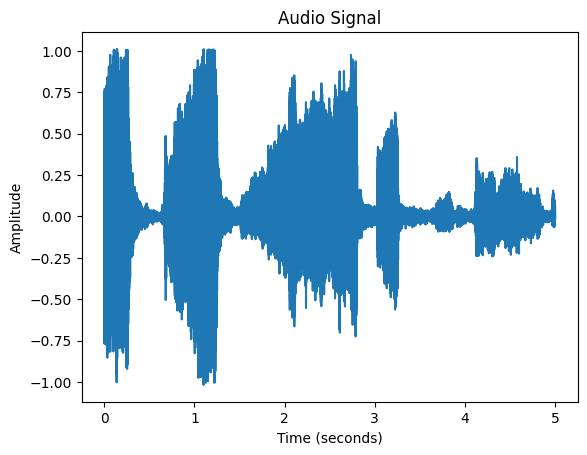

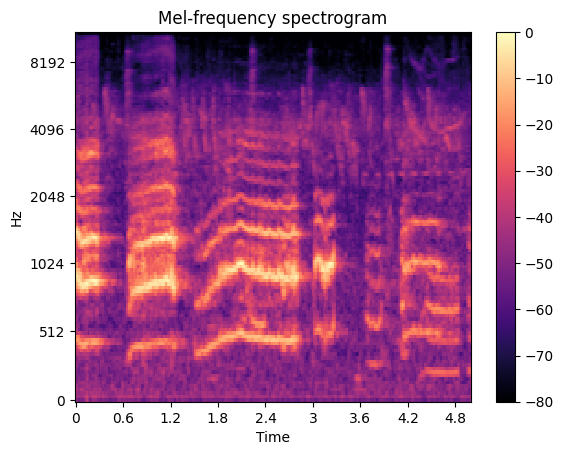

In [7]:
# 🚨TODO🚨
track, sr = librosa.load("/content/ESC50/audio/2-72268-A-6.wav")
print(f'Number of samples: {len(track)}')
print(f'Sampling rate: {sr}')
print(f'Duration: {len(track)/sr} seconds')
duration = len(track)/sr

time_in_seconds = np.linspace(0, duration, len(track))

# Plot the signal:
plt.plot(time_in_seconds, track)
plt.ylabel('Amplitude')
plt.xlabel('Time (seconds)')
plt.title('Audio Signal')
plt.show()

S = librosa.feature.melspectrogram(y=track, sr=sr)
fig, ax = plt.subplots()
S_power = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_power, x_axis='time',
                         y_axis='mel', sr=sr, ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='Mel-frequency spectrogram')

Audio(track, rate=sr)

#### Quick check: class distribution
Before we move on, let's also look at some aggregate statistics about the classes in the dataset:

**Deliverables**:
1. Print the number of files total.
2. Print the number of classes total.
3. Plot the number of files per class in a bar chart. For your own understanding: are the classes balanced? Unbalanced?

In [16]:
# 🚨TODO🚨
df = pd.read_csv('/content/ESC50/meta/esc50.csv')
df.head(5)

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


number of total files is 2000
 prinitng the different categories and distribution : category
dog                 40
chirping_birds      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep               40
water_drops         40
church_bells        40
clock_alarm         40
keyboard_typing     40
wind                40
footsteps           40
frog                40
cow                 40
brushing_teeth      40
car_horn            40
crackling_fire      40
helicopter          40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
hand_saw            40
coughing            40
glass_breaking      40
snoring             40
toilet_flu

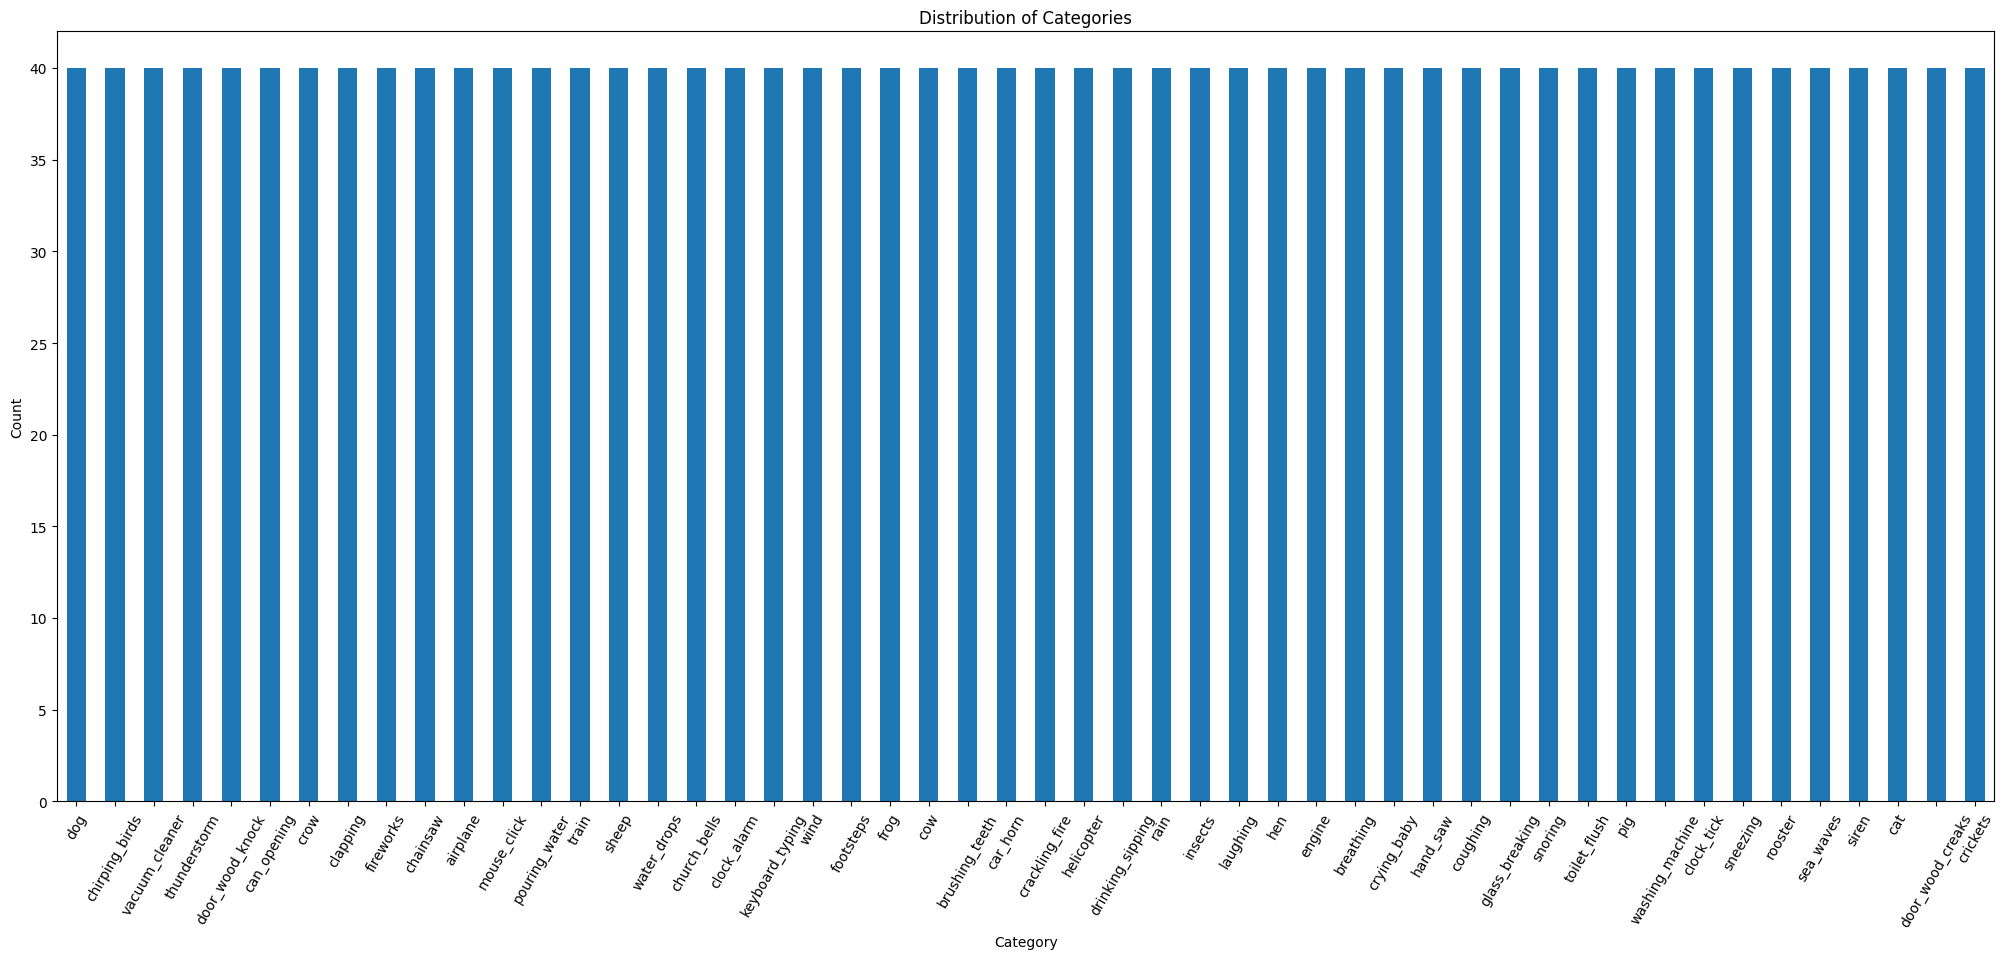

In [ ]:

print(f"number of total files is {len(df)}")
print(f" prinitng the different categories and distribution : {df['category'].value_counts()}")

counts = df['category'].value_counts()

# Plot as a bar chart
plt.figure(figsize=(25, 10))
counts.plot(kind='bar')


plt.title('Distribution of Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=60)
plt.show()

We have a balanced dataset of 40 examples per class (50 classes).

### Designing MFCC features [1pt]
**Deliverables**

- Implement an MFCC feature extraction method as discussed in class.
    - You may ***not*** use librosa's built in MFCC method for this.
    - You ***may*** use numpy or scipy built-in methods as helper functions, and you can use the MelSpectrogram method from librosa.
- Using an ESC-50 audio file, plot the log-mel Spectrogram and MFCCs of this signal using your method. The MFCC plot should contain time on the x-axis and coefficient index on y-axis.


In [ ]:
def get_mfcc_features(mel_spec, m=None):
    """ Compute MFCC features from a mel spectrogram.
    Always drop the first 2 coefficients, and use `m`
    to decide how many remaining coefficients to keep after those are dropped.
    i.e., keep up to coefficient `m` (index m+2 before dropping [0-1]

    Tips:
    - Use DCT-Type II
    - Include norm="ortho" in your DCT method call for normalization.

    Parameters
    ----------
    mel_spec : np.ndarray, shape (n_mels, n_frames)
        Mel spectrogram (in power).
    m: Discard cepstral coefficients beyond this index m.

    Returns
    -------
    mfcc : np.ndarray, shape (n_mfcc, n_frames)
        Matrix of retained MFCC features.

    Returns:
      - mfcc_trunc: (m, n_frames) MFCC features, with appropriate coefficients dropped.
      - mfcc_trunc_full:(n_mels, n_frames) same information as mfcc_trunc, but of the original length.
        (dropped coefficients zeroed, that we'll use for envelope plots)
      - mel_db: (n_mels, n_frames) log-mel spectrogram
    """
    mel_db = librosa.power_to_db(mel_spec, ref=np.max) ###turns the input from power to db amplitude
    full_mfcc = dct(mel_db,norm="ortho", axis = 0)
    mfcc_trunc = full_mfcc[2:m+2, :]
    mfcc_trunc_full = np.zeros_like(full_mfcc) #zero'd sized as full mfcc
    mfcc_trunc_full[2:m+2, :] = mfcc_trunc


    return mfcc_trunc, mfcc_trunc_full, mel_db


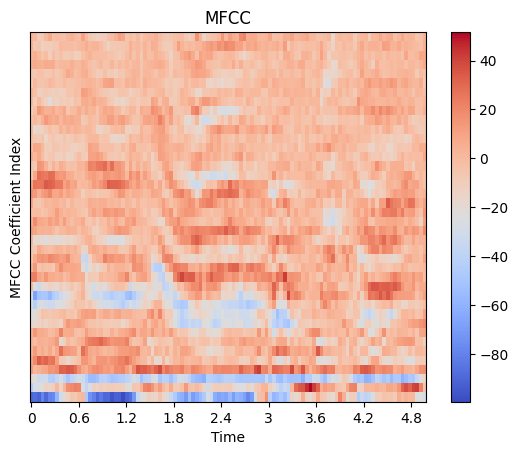

In [ ]:
# 🚨TODO🚨
# Code to test and plot your MFCC method
# Use these default parameters:
n_fft = 4096
window_length = 2048
hop_length = 1024
n_mels = 128
sr = 22050
fmin = 200
fmax = 8000
S = librosa.feature.melspectrogram(y=track, sr=sr,n_fft=n_fft, win_length = window_length,fmin = fmin, fmax = fmax, hop_length = hop_length)
S_mfcc, full, meldb = get_mfcc_features(S, 40)

fig, ax = plt.subplots()
img = librosa.display.specshow(S_mfcc, sr=sr, ax=ax,x_axis='time', hop_length=hop_length)
fig.colorbar(img, ax=ax)

ax.set(title='MFCC', ylabel='MFCC Coefficient Index')
plt.show()



In [ ]:
full.shape #two first mfccs zeroed, 40 mfccs, and the rest are zeroed up to the original n_mels

(128, 108)

In [ ]:
S_mfcc.shape #my truncated mfcc

(40, 108)

In [ ]:
meldb.shape #the input spectrogram but db'd this time

(128, 108)

### Understanding MFCC: plotting the spectral envelope [1pt]
**Deliverables:**

To get a better understanding of the effect of MFCC transformation, create the following sequence of plots, for the audio file **ESC50/audio/5-198411-A-20.wav**:
1. Log Mel spectrogram
2. MFCC
3. Spectral envelope: log mel *spectrum* and reconstructed spectrum from your MFCCs, both at frame 54, overlayed on the same plot. Show 4 versions of this plot, for `m={5,10,12,40}` in your MFCC function to observe the effect.

**Guidelines and tips:**
- Take care in naming your axis appropriately and ensuring that the scaling of each plot makes sense - we will be looking for this as one aspect of grading here.
- Tip 1: You will want to reconstruct using the full-length MFCCs (containing zero'd coefficients).
- Tip 2: Because the first two coefficients are dropped, your enevelope may appear DC-shifted when reconstructed. To get around this you can add the mean of the log mel spectrogram back to the reconstructed spectrum

Number of samples: 110250
Sampling rate: 22050
Duration: 5.0 seconds


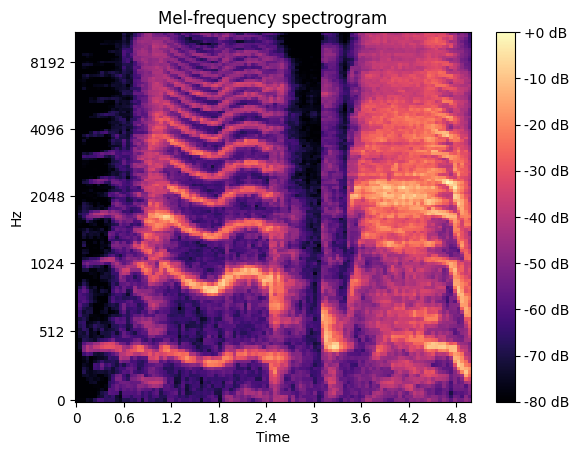

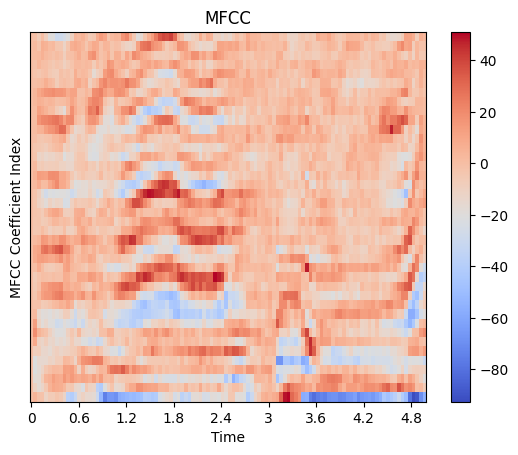

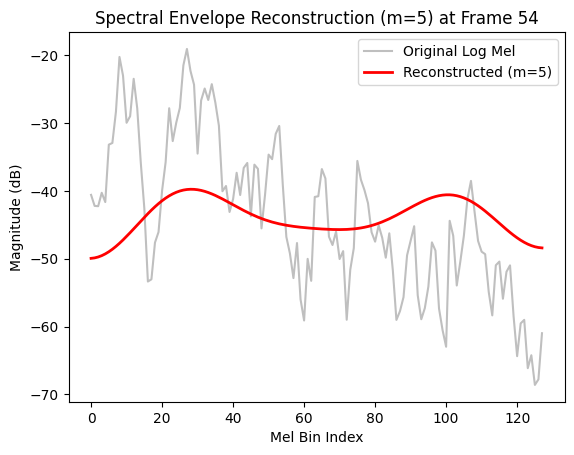

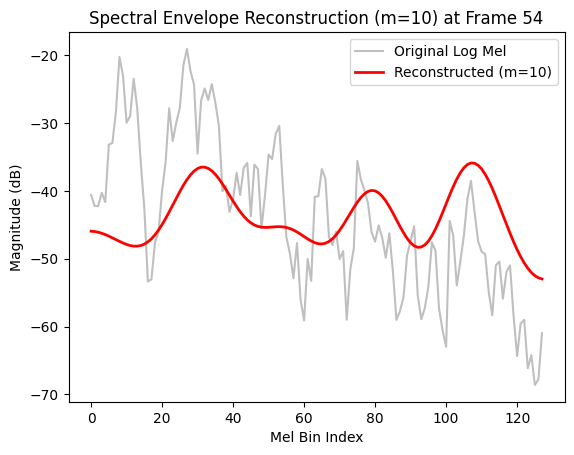

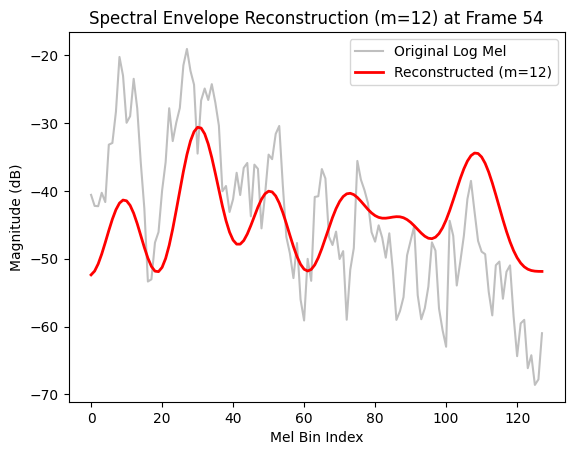

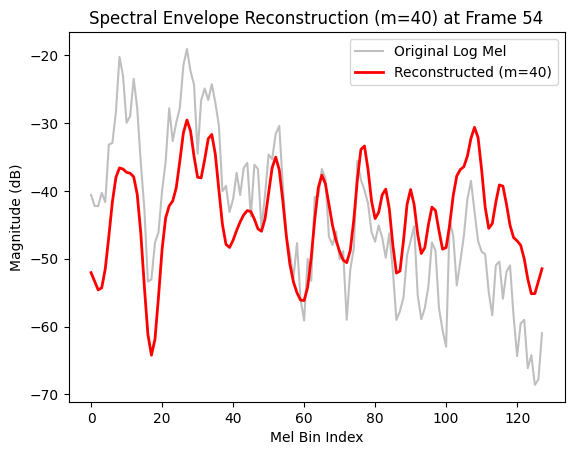

In [ ]:
# Use these default parameters
n_fft = 4096
window_length = 2048
hop_length = 1024
n_mels = 128
sr = 22050
fmin = 200
fmax = 8000

# 🚨TODO 🚨 your code and plots for the above.

track, sr = librosa.load("/content/ESC50/audio/5-198411-A-20.wav")
print(f'Number of samples: {len(track)}')
print(f'Sampling rate: {sr}')
print(f'Duration: {len(track)/sr} seconds')
duration = len(track)/sr

time_in_seconds = np.linspace(0, duration, len(track))
# Plot the signal:
S = librosa.feature.melspectrogram(y=track, sr=sr,n_fft=n_fft, win_length = window_length,fmin = fmin, fmax = fmax, hop_length = hop_length, n_mels = n_mels)
fig, ax = plt.subplots()
S_power = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_power, x_axis='time',hop_length=hop_length,
                         y_axis='mel', sr=sr, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')

ax.set(title='Mel-frequency spectrogram')


S_mfcc, full, meldb = get_mfcc_features(S, 40)

fig, ax = plt.subplots()
img = librosa.display.specshow(S_mfcc, sr=sr, ax=ax,x_axis='time', hop_length=hop_length)
fig.colorbar(img, ax=ax, )

ax.set(title='MFCC', ylabel='MFCC Coefficient Index')
plt.show()

####### Spectral Envelope#####
m=[5,10,12,40] ##list to iterate through different m
meldb = meldb[: ,54] #the specific spectral envelope at frame 54
mean_mel_db = np.mean(meldb) #taking the mean to add on to the idct envelope to compensate for 2 first dropped coefficients

for i in m:
  _ ,full, _ = get_mfcc_features(S, i)####The "full" but with only 40 mfcc's and the rest are zeroed including first 2.
  full = full[:, 54]
  full_only_forty = idct(full, axis=0, norm='ortho') ####this cepstrum converted back into the spectral domain


  plt.plot(meldb, label='Original Log Mel', alpha=0.5, color='gray')
  plt.plot(full_only_forty+mean_mel_db, label=f'Reconstructed (m={i})', color='red', linewidth=2)

  plt.title(f'Spectral Envelope Reconstruction (m={i}) at Frame 54')
  plt.xlabel('Mel Bin Index')
  plt.ylabel('Magnitude (dB)')
  plt.legend()
  plt.show()



  Audio(track, rate=sr)


# Part 2: Sound Event Classification [3 pts + 1 pt extra credit available]
You will design, train, and evaluate three model configurations for sound event classification:

The models:
1. MLP, using MFCC features
2. MLP, using log Mel spectrogram features
3. CNN (**1D**), using log Mel spectrogram features

Extra credit [1pt]:
1. CNN (**2D**), using log Mel spectrogram features. If you are doing the extra credit, follow the deliverables for the prior 3 models here, as well as the written question for full credit.

Some tips on the components of the pipeline you'll need to setup:
- Dataloader for ESC-50, retrieves (MFCC/Mel feature, label) per file. Handles train/validation/test splits by fold specified in ESC metadata.
- Model architecture for each.
- Training and validation pipeline.
- Evaluation given a trained model on the test set.




#### **Deliverables**


**1. Model investigation across features and architectures** [2.5 pts]
- Train the three model configurations above for multi-class sound event classification with ESC-50.
- Report **overall accuracy** of each model and **F1-score** of the top and bottom-3 performing classes per configuration (over 3-fold cross validation).

**2. Explanation of results and parameter choices for each model configuration** [0.5 pts]
- Brief written explanation justifying (1) model design/parameter choices for each of the three configurations, and (2) intuition about model performance. See prompt below for details.

**Guidelines for model design:**
- Final model configurations should be reported using **3-fold cross-validation**, in which 3 train/validation/test splits are chosen at random. ESC-50's metadata file has each audio clip labeled with a fold number already (Fold #1-5). Ideally we would do 5-fold, but let's stick with 3 for the scope of this assignment for computational purposes. Feel free to run individual folds (or smaller scale overfitting-style experiments) for early experimentation.
- This is an exercise in ***careful architecture choices for a simple model*** for the task and features at hand. The focus should be on an intentional and informed choices of layer parameters (e.g. hidden dimensions, pooling, model initialization, etc.)
- Model selection should be in terms of minimum validation loss.
- Your model parameter counts should not exceed 200k.
- You will likely want to use some feature normalization as discussed in class.


Baselines:
- As a reference, I was able to achieve ~20-30% test accuracy (depending on test fold) using a 90k parameter simple MLP+MFCC model. I used a learning rate of 1e-3, batch size 16, and trained for 10 epochs.


## 1: Model investigation and reports - 💡YOUR CODE HERE💡
Model configurations:
1. MLP, using MFCC features
2. MLP, using log Mel spectrogram features
3. CNN (**1D**), using log Mel spectrogram features

Cleary report results (refer above for what is required).

In [ ]:
# 🚨TODO🚨 - Freeform code for this section.
# Up to you how you want to structure things!

In [ ]:
df

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
...,...,...,...,...,...,...,...
1995,5-263831-B-6.wav,5,6,hen,False,263831,B
1996,5-263902-A-36.wav,5,36,vacuum_cleaner,False,263902,A
1997,5-51149-A-25.wav,5,25,footsteps,False,51149,A
1998,5-61635-A-8.wav,5,8,sheep,False,61635,A


In [ ]:
distribution = pd.crosstab(df['category'], df['fold'])


print(distribution.head(40)) #to see the different category and distribution

fold              1  2  3  4  5
category                       
airplane          8  8  8  8  8
breathing         8  8  8  8  8
brushing_teeth    8  8  8  8  8
can_opening       8  8  8  8  8
car_horn          8  8  8  8  8
cat               8  8  8  8  8
chainsaw          8  8  8  8  8
chirping_birds    8  8  8  8  8
church_bells      8  8  8  8  8
clapping          8  8  8  8  8
clock_alarm       8  8  8  8  8
clock_tick        8  8  8  8  8
coughing          8  8  8  8  8
cow               8  8  8  8  8
crackling_fire    8  8  8  8  8
crickets          8  8  8  8  8
crow              8  8  8  8  8
crying_baby       8  8  8  8  8
dog               8  8  8  8  8
door_wood_creaks  8  8  8  8  8
door_wood_knock   8  8  8  8  8
drinking_sipping  8  8  8  8  8
engine            8  8  8  8  8
fireworks         8  8  8  8  8
footsteps         8  8  8  8  8
frog              8  8  8  8  8
glass_breaking    8  8  8  8  8
hand_saw          8  8  8  8  8
helicopter        8  8  8  8  8
hen     

In [ ]:
# Our simple dataset class
class AudioDataset(Dataset):
    def __init__(self, data, audio_directory,feature_type="mfcc", n_mfcc=40, n_fft = 4096,window_length = 2048,hop_length = 1024,n_mels = 128,sr = 22050,fmin = 200,fmax = 8000):
        self.data = data  # (ex: numpy array of (n_samples, n_features), list of filepaths etc.)
        self.audio_directory = audio_directory
        self.feature_type = feature_type # "mfcc" or "spectrogram"
        self.n_mfcc = n_mfcc
        self.sr = sr
        self.n_fft = n_fft
        self.window_length = window_length
        self.hop_length = hop_length
        self.fmin = fmin
        self.fmax = fmax
        # self.min_val = None ###for mix-max scaling
        # self.max_val = None ####for min- max scaling
        self.mean_val = None ###for for mean std scaling
        self.std_val = None ####for for mean std scaling


        print(f'Number of data samples: {len(self.data)}')

    def __len__(self):
        return len(self.data)  # Return dataset size, this is just a formality

    def set_stats(self, mean_val, std_val):
        """applied standartization from the training set"""
        self.mean_val = mean_val
        self.std_val = std_val

    # Get item is the core method that retrieves one sample (and a label, optionally)
    def __getitem__(self, idx):
        # idx is the index into your full dataset (e.g. sample at index 2 from your dataset)
        file_index = self.data.iloc[idx] #the specific file
        file_path = os.path.join(self.audio_directory, file_index['filename']) #gets its path
        label = file_index["target"]
        audio, _ = librosa.load(file_path, sr= self.sr, duration = 5)
        S = librosa.feature.melspectrogram(y=audio, sr=self.sr,n_fft=self.n_fft, win_length = self.window_length,fmin = self.fmin, fmax = self.fmax, hop_length =  self.hop_length)

        #for mfcc:
        if self.feature_type == "mfcc":
          S_mfcc, _, _ = get_mfcc_features(S, self.n_mfcc)
          mfcc_mean = np.mean(S_mfcc, axis = 1) #averaging across time for MLP
          mfcc_std = np.std(S_mfcc, axis=1)
          features = np.concatenate((mfcc_mean, mfcc_std)) ###concatenate mean and standard deviation for the model
        #for log mel spectrogram:
        elif self.feature_type == "spectrogram":
          S_db = librosa.power_to_db(S, ref=np.max) ###turns the input from power to db amplitude
          spec_mean = np.mean(S_db, axis =1) ##average mel bins across time
          spec_std = np.std(S_db, axis =1) ##standard deviation across time
          features =np.concatenate((spec_mean, spec_std))
                #if given wrong input value
        else:
          print("input feature type not recognized - accepts 'mfcc' or 'spectrogram'")

        # --- standardization Scaling Logic ---
        if self.mean_val is not None and self.std_val is not None: ####if i input the mean and std values from training
            features = (features - self.mean_val) / (self.std_val + 1e-6) ##adding a small number to prevent division by zero in edge case
            #normalize the features



        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)  # Return sample and label

In [ ]:
df

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
...,...,...,...,...,...,...,...
1995,5-263831-B-6.wav,5,6,hen,False,263831,B
1996,5-263902-A-36.wav,5,36,vacuum_cleaner,False,263902,A
1997,5-51149-A-25.wav,5,25,footsteps,False,51149,A
1998,5-61635-A-8.wav,5,8,sheep,False,61635,A


In [22]:
# Check if a GPU (CUDA) is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print(f"Using device: {device}")

Using device: cpu


In [23]:
path = "/content/ESC50/audio"

# Create dataset and DataLoader
dataset = AudioDataset(df,path, feature_type= "mfcc")

# Dataloader is an iterable wrapper class for dataset
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
# Iterate over DataLoader
for batch in dataloader:
    inputs, targets = batch
    print(inputs.shape, targets.shape)
    break  # Stop after first batch for demo

# Note that if you are using different train/val/test splits, usually
# you create separate dataset instances+dataloaders for each of the splits

NameError: name 'AudioDataset' is not defined

In [18]:
from sklearn.metrics import f1_score
# (3 different folds)
configurations = [
    ([1, 2, 3], 4, 5),
    ([2, 3, 4], 5, 1),
    ([3, 4, 5], 1, 2)]

for train_idx, val_idx, test_idx in configurations:
    train_df = df[df['fold'].isin(train_idx)]
    val_df   = df[df['fold'] == val_idx]
    test_df  = df[df['fold'] == test_idx]
    print("Folds present in train_df:", train_df['fold'].unique())

    print(f"Processing Run: Train on {train_idx}, Test on {test_idx}")

Folds present in train_df: [1 2 3]
Processing Run: Train on [1, 2, 3], Test on 5
Folds present in train_df: [2 3 4]
Processing Run: Train on [2, 3, 4], Test on 1
Folds present in train_df: [3 4 5]
Processing Run: Train on [3, 4, 5], Test on 2


In [ ]:

class DeepLinearModel(nn.Module):
    def __init__(self, input_dim=80, n_classes=50):
        super(DeepLinearModel, self).__init__()

        #layer 1
        self.layer1 = nn.Linear(input_dim, 256)
        self.dropout = nn.Dropout(p=0.2)

        #layer 2
        self.layer2 = nn.Linear(256, 128)
        self.layer3 = nn.Linear(128, n_classes) #layer 3

    def forward(self, x):
        # First layer + activation
        x = F.relu(self.layer1(x))
        x = self.dropout(x)
        # second layer + activation
        x = F.relu(self.layer2(x))
        x = self.dropout(x)

        # final output
        logits = self.layer3(x)
        return logits

In [ ]:
print_model(DeepLinearModel())

Model's state dictionary (stored weights):
   layer1.weight 	 (256, 80)
   layer1.bias 	 (256,)
   layer2.weight 	 (128, 256)
   layer2.bias 	 (128,)
   layer3.weight 	 (50, 128)
   layer3.bias 	 (50,)
In total, this network has  60082  trainable parameters


In [ ]:
len(train_df)

1200

In [8]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.5 MB/s eta 0:00:00


In [9]:
from torchmetrics.classification import MulticlassF1Score

In [ ]:
from pandas.core.indexes import category
results = []
results_test = []
global_f1_sum = torch.zeros(50).to(device) ###global average f1
mapping = dict(zip(df['target'], df['category'])) ###a mapping that connects target_id to category for f1 later on
for run_idx, (train_idx, val_idx, test_idx) in enumerate(configurations):
    best_run_val_loss = float('inf') ##to keep track of
    run_model_path = f'best_model_MFCC_run_{run_idx+1}.pth'
    print(f"\n--- Starting Run {run_idx + 1}/3 ---")

    #split the DataFrame for this specific run
    train_df = df[df['fold'].isin(train_idx)]
    val_df   = df[df['fold'] == val_idx]
    test_df  = df[df['fold'] == test_idx]




    # slicing a dataset for each subset
    train_ds = AudioDataset(train_df, path, feature_type="mfcc")
    val_ds   = AudioDataset(val_df, path, feature_type="mfcc")
    test_ds  = AudioDataset(test_df, path, feature_type="mfcc")


    ##calculating min-max from training
    print("Calculating Min-Max scaling from training data...")
    all_train_feats = []
    for i in range(len(train_ds)):
        feat, _ = train_ds[i] # takes original feature (unscaled)
        all_train_feats.append(feat) ###adds to all_train_feats list

    # Stack to vector and find min and max value across all 1200 files
    # Corrected for Mean and Std
    all_train_feats = torch.stack(all_train_feats)
    train_mean = all_train_feats.mean(dim=0).numpy() # Removed .values
    train_std = all_train_feats.std(dim=0).numpy()

    ###apply the min max of training to validation and test
    train_ds.set_stats(train_mean, train_std)
    val_ds.set_stats(train_mean, train_std)
    test_ds.set_stats(train_mean, train_std)

    #create DataLoaders
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

    #initialize Model, Optimizer, and Loss
    #input_dim = 40
     # Model setup
    model = DeepLinearModel().to(device)

    # Optimizer setup, on all of our model parameters
    opt = torch.optim.Adam(model.parameters(), lr=0.001)

    # Define the loss function
    loss_fn = nn.CrossEntropyLoss().to(device)



# TRAINING LOOP

# Loop through the entire [training] data each "epoch"
# So you will go through every "batch" of data inside this epoch
    epochs = 10
    for epoch in range(epochs):
    # This tells your model that you are in training mode and not testing mode
    # For our simple case this doesn't do much, but more complex layers such as Dropout
    # behave differently in training vs. evaluation mode
      model.train()
      total_loss = 0.0
      for batch in train_loader:
        inputs, targets = batch
        # Move them to the GPU and overwrite the old variables
        inputs = inputs.to(device)
        targets = targets.to(device)
        # Set the gradients to 0 before running the network on the data each iteration, so that
        # loss gradients can be computed correctly during backpropagation
        opt.zero_grad()
        # print(f"Model input shape (batch): {inputs.shape}")

        # Get the output of the network on the data
        # Note that these are probabilities, *not* class labels!
        output = model(inputs)
        # print(f"Model output shape (batch): {output.shape}")

        # Measure the "loss" using mean squared error
        loss = loss_fn(output, targets)

        # This calculates the gradients, performing backpropagation to propagate
        # errors backward through the network's weights
        loss.backward()

        # This updates the network weights based on the freshly-computed gradient
        # now stored alongside each weight
        opt.step()

        # Accumulate the total loss per epoch
        total_loss += loss.item()

      print(f"Training Epoch {epoch+1}/{epochs}, Train Loss: {total_loss / len(train_loader):.4f}")

    # VALIDATION LOOP
    # The validation loop
      model.eval()
      total_val_loss = 0.0
      correct_val = 0
      total_val = 0

      with torch.no_grad():  # Disable gradient computation
        for batch in val_loader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_val_loss += loss.item()

            # Compute validation accuracy
            _, predicted = torch.max(outputs, dim=1)
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)
            #print((total_val))

      avg_val_loss = total_val_loss / len(val_loader)
      val_accuracy = correct_val / total_val
      if avg_val_loss < best_run_val_loss:  ####to save the best model for this run (minimum validation loss, as required)
            best_run_val_loss = avg_val_loss
            best_run_acc = val_accuracy#### saves the best models validation accuracy score to append later
            torch.save(model.state_dict(), run_model_path) # Save run-specific best
            print(f"Run {run_idx+1}: New best model at epoch {epoch+1}")


    # Print results for current epoch
      print(f"Validation Epoch {epoch+1}/{epochs}, Val loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}\n")
    results.append(best_run_acc) ###append only the best accuracy result from the best model in this run

# --- After the 10 epochs are TOTALLY done -TEST!---
    f1_metric = MulticlassF1Score(num_classes=50, average=None).to(device) ###to measure F1
    model.load_state_dict(torch.load(run_model_path))
    model.eval()
    num_correct = 0
    with torch.no_grad():
      for batch in test_loader:
          inputs, targets = batch
          inputs, targets = inputs.to(device), targets.to(device)
          output = model(inputs)
          predictions = torch.argmax(output, dim=-1)
          num_correct += (predictions == targets).sum().item()
          f1_metric.update(predictions, targets)

    all_f1s = f1_metric.compute()
    global_f1_sum += all_f1s
    #print(all_f1s) wanted to see the f1's changine and accumulating into global f1
    #print(global_f1_sum)



    # clear the metric for the next run (since doing 3-fold)
    f1_metric.reset()


    # Store the final grade for this run
    test_acc = num_correct / len(test_df)
    results_test.append(test_acc)
    print(f"Current Run test accuracy score is {test_acc}.")
    print(f"Run {run_idx+1} complete.")

final_avg_f1s = global_f1_sum / len(configurations) ###devides by 3, to get average
# Get Top 3 and Bottom 3 using topk
top_f1, top_idx = torch.topk(final_avg_f1s, 3)
bot_f1, bot_idx = torch.topk(final_avg_f1s, 3, largest=False)

print(f"Top Classes Indices: {top_idx.tolist()}")
print(f"Top Classes Categories: {mapping[top_idx[0].item()]},{mapping[top_idx[1].item()]},{mapping[top_idx[2].item()]}")
###to turn the inex number into categories, item() for getting them from tensor to int
print(f"Top F1 Scores: {top_f1.tolist()}")
print(f"Bottom Classes Indices: {bot_idx.tolist()}")
print(f"Bottom Classes Categories: {mapping[bot_idx[0].item()]},{mapping[bot_idx[1].item()]},{mapping[bot_idx[2].item()]}")
print(f"Bottom F1 Scores: {bot_f1.tolist()}")

#  Final Report
print(f"Average 3-Fold Validation Accuracy: {np.mean(results):.2f}")

print(f"Average 3-Fold Test Accuracy: {np.mean(results_test):.2f}")




--- Starting Run 1/3 ---
Number of data samples: 1200
Number of data samples: 400
Number of data samples: 400
Calculating Min-Max scaling from training data...
Training Epoch 1/10, Train Loss: 3.7173
Run 1: New best model at epoch 1
Validation Epoch 1/10, Val loss: 3.3941, Val Accuracy: 0.1425

Training Epoch 2/10, Train Loss: 3.0846
Run 1: New best model at epoch 2
Validation Epoch 2/10, Val loss: 2.9277, Val Accuracy: 0.1700

Training Epoch 3/10, Train Loss: 2.6209
Run 1: New best model at epoch 3
Validation Epoch 3/10, Val loss: 2.6646, Val Accuracy: 0.2600

Training Epoch 4/10, Train Loss: 2.2921
Run 1: New best model at epoch 4
Validation Epoch 4/10, Val loss: 2.5237, Val Accuracy: 0.3200

Training Epoch 5/10, Train Loss: 2.0357
Run 1: New best model at epoch 5
Validation Epoch 5/10, Val loss: 2.4254, Val Accuracy: 0.3325

Training Epoch 6/10, Train Loss: 1.8121
Validation Epoch 6/10, Val loss: 2.4359, Val Accuracy: 0.3400

Training Epoch 7/10, Train Loss: 1.6474
Validation Epoch

**MLP + MFCC Model Summary**
We have an avarage score of 0.30 Test accuracy.
Throughout the 3 runs of different splits,
these are the highest F1 Score categories:
clock_alarm, toilet_flush, and rooster.


1.  toilet_flush (0.72)
2.  clock_alarm (0.66)
3.  sheep (0.61)


bottom 3 F1 scores (as they are zero, there might be more 0.0 F1 score classes)


1.   fireworks
2.   footsteps
3.   wind

In this architecture I used the mean and standard deviation of the 40 MFCC's, resulting in a feature vector of 80.
I started by expanding the features to 256, then slowly narrowing it to 2nd layer of 128, and then 3rd layer to 50.
I created a dropout of 0.2 between each layer, to work only on a subset of the original neurons during training (basically turns some of them off).
In total, this network has  60082  trainable parameters. It is a pretty minimal architecture.
By concatenating the features across time, I suppose the winning categories are generally consistent through time, while the wind or fireworks for example are more changing throughout and averaging them didn't help the model identify a specific pattern, and might sound like other noise categories, or, the one pop of firework averages out with the rest of the sound clip which is silent.

In [ ]:
######Slightly different model for the spectrogram, especially regarding the input output dimensions, and added batch normalization
class DeepLinearModelSpectrogram(nn.Module):
    def __init__(self, input_dim=256, n_classes=50):
        super(DeepLinearModelSpectrogram, self).__init__()

        #layer 1
        self.layer1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)

        #layer 2
        self.layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.layer3 = nn.Linear(128, n_classes) #layer 3
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # First layer + activation
        x = self.layer1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # second layer + activation
        x = self.layer2(x) #
        x = self.bn2(x)    #
        x = F.relu(x)
        x = self.dropout(x)
        # final output
        logits = self.layer3(x)
        return logits

In [ ]:
######MLP + Spectrogram

from pandas.core.indexes import category
results = []
results_test = []
global_f1_sum = torch.zeros(50).to(device) ###global average f1
mapping = dict(zip(df['target'], df['category'])) ###a mapping that connects target_id to category for f1 later on
for run_idx, (train_idx, val_idx, test_idx) in enumerate(configurations):
    best_run_val_loss = float('inf') ##to keep track of
    run_model_path = f'best_model_spec_run_{run_idx+1}.pth'
    print(f"\n--- Starting Run {run_idx + 1}/3 ---")

    #split the DataFrame for this specific run
    train_df = df[df['fold'].isin(train_idx)]
    val_df   = df[df['fold'] == val_idx]
    test_df  = df[df['fold'] == test_idx]




    # slicing a dataset for each subset
    train_ds = AudioDataset(train_df, path, feature_type="spectrogram")
    val_ds   = AudioDataset(val_df, path, feature_type="spectrogram")
    test_ds  = AudioDataset(test_df, path, feature_type="spectrogram")


    ##calculating min-max from training
    print("Calculating Min-Max scaling from training data...")
    all_train_feats = []
    for i in range(len(train_ds)):
        feat, _ = train_ds[i] # takes original feature (unscaled)
        all_train_feats.append(feat) ###adds to all_train_feats list

    # Stack to vector and find min and max value across all 1200 files
    # Corrected for Mean and Std
    all_train_feats = torch.stack(all_train_feats)
    train_mean = all_train_feats.mean(dim=0).numpy() # Removed .values
    train_std = all_train_feats.std(dim=0).numpy()

    ###apply the min max of training to validation and test
    train_ds.set_stats(train_mean, train_std)
    val_ds.set_stats(train_mean, train_std)
    test_ds.set_stats(train_mean, train_std)

    #create DataLoaders
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

    #initialize Model, Optimizer, and Loss
    #input_dim = 40
     # Model setup
    model = DeepLinearModelSpectrogram().to(device)

    # Optimizer setup, on all of our model parameters
    opt = torch.optim.Adam(model.parameters(), lr=0.001)

    # Define the loss function
    loss_fn = nn.CrossEntropyLoss().to(device)



# TRAINING LOOP

# Loop through the entire [training] data each "epoch"
# So you will go through every "batch" of data inside this epoch
    epochs = 10
    for epoch in range(epochs):
    # This tells your model that you are in training mode and not testing mode
    # For our simple case this doesn't do much, but more complex layers such as Dropout
    # behave differently in training vs. evaluation mode
      model.train()
      total_loss = 0.0
      for batch in train_loader:
        inputs, targets = batch
        # Move them to the GPU and overwrite the old variables
        inputs = inputs.to(device)
        targets = targets.to(device)
        # Set the gradients to 0 before running the network on the data each iteration, so that
        # loss gradients can be computed correctly during backpropagation
        opt.zero_grad()
        # print(f"Model input shape (batch): {inputs.shape}")

        # Get the output of the network on the data
        # Note that these are probabilities, *not* class labels!
        output = model(inputs)
        # print(f"Model output shape (batch): {output.shape}")

        # Measure the "loss" using mean squared error
        loss = loss_fn(output, targets)

        # This calculates the gradients, performing backpropagation to propagate
        # errors backward through the network's weights
        loss.backward()

        # This updates the network weights based on the freshly-computed gradient
        # now stored alongside each weight
        opt.step()

        # Accumulate the total loss per epoch
        total_loss += loss.item()

      print(f"Training Epoch {epoch+1}/{epochs}, Train Loss: {total_loss / len(train_loader):.4f}")

    # VALIDATION LOOP
    # The validation loop
      model.eval()
      total_val_loss = 0.0
      correct_val = 0
      total_val = 0

      with torch.no_grad():  # Disable gradient computation
        for batch in val_loader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_val_loss += loss.item()

            # Compute validation accuracy
            _, predicted = torch.max(outputs, dim=1)
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)
            #print((total_val))

      avg_val_loss = total_val_loss / len(val_loader)
      val_accuracy = correct_val / total_val
      if avg_val_loss < best_run_val_loss:  ####to save the best model for this run (minimum validation loss, as required)
            best_run_val_loss = avg_val_loss
            best_run_acc = val_accuracy#### saves the best models validation accuracy score to append later
            torch.save(model.state_dict(), run_model_path) # Save run-specific best
            print(f"Run {run_idx+1}: New best model at epoch {epoch+1}")


    # Print results for current epoch
      print(f"Validation Epoch {epoch+1}/{epochs}, Val loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}\n")
    results.append(best_run_acc) ###append only the best accuracy result from the best model in this run

# --- After the 10 epochs are TOTALLY done -TEST!---
    f1_metric = MulticlassF1Score(num_classes=50, average=None).to(device) ###to measure F1
    model.load_state_dict(torch.load(run_model_path))
    model.eval()
    num_correct = 0
    with torch.no_grad():
      for batch in test_loader:
          inputs, targets = batch
          inputs, targets = inputs.to(device), targets.to(device)
          output = model(inputs)
          predictions = torch.argmax(output, dim=-1)
          num_correct += (predictions == targets).sum().item()
          f1_metric.update(predictions, targets)

    all_f1s = f1_metric.compute()
    global_f1_sum += all_f1s
    #print(all_f1s) wanted to see the f1's changine and accumulating into global f1
    #print(global_f1_sum)



    # clear the metric for the next run (since doing 3-fold)
    f1_metric.reset()


    # Store the final grade for this run
    test_acc = num_correct / len(test_df)
    results_test.append(test_acc)
    print(f"Current Run test accuracy score is {test_acc}.")
    print(f"Run {run_idx+1} complete.")

final_avg_f1s = global_f1_sum / len(configurations) ###devides by 3, to get average
# Get Top 3 and Bottom 3 using topk
top_f1, top_idx = torch.topk(final_avg_f1s, 3)
bot_f1, bot_idx = torch.topk(final_avg_f1s, 3, largest=False)

print(f"Top Classes Indices: {top_idx.tolist()}")
print(f"Top Classes Categories: {mapping[top_idx[0].item()]},{mapping[top_idx[1].item()]},{mapping[top_idx[2].item()]}")
###to turn the inex number into categories, item() for getting them from tensor to int
print(f"Top F1 Scores: {top_f1.tolist()}")
print(f"Bottom Classes Indices: {bot_idx.tolist()}")
print(f"Bottom Classes Categories: {mapping[bot_idx[0].item()]},{mapping[bot_idx[1].item()]},{mapping[bot_idx[2].item()]}")
print(f"Bottom F1 Scores: {bot_f1.tolist()}")

#  Final Report
print(f"Average 3-Fold Validation Accuracy: {np.mean(results):.2f}")

print(f"Average 3-Fold Test Accuracy: {np.mean(results_test):.2f}")




--- Starting Run 1/3 ---
Number of data samples: 1200
Number of data samples: 400
Number of data samples: 400
Calculating Min-Max scaling from training data...
Training Epoch 1/10, Train Loss: 3.5338
Run 1: New best model at epoch 1
Validation Epoch 1/10, Val loss: 3.1238, Val Accuracy: 0.1775

Training Epoch 2/10, Train Loss: 3.0616
Run 1: New best model at epoch 2
Validation Epoch 2/10, Val loss: 2.7763, Val Accuracy: 0.2775

Training Epoch 3/10, Train Loss: 2.8050
Run 1: New best model at epoch 3
Validation Epoch 3/10, Val loss: 2.6646, Val Accuracy: 0.2975

Training Epoch 4/10, Train Loss: 2.6267
Run 1: New best model at epoch 4
Validation Epoch 4/10, Val loss: 2.4783, Val Accuracy: 0.3300

Training Epoch 5/10, Train Loss: 2.4752
Run 1: New best model at epoch 5
Validation Epoch 5/10, Val loss: 2.3894, Val Accuracy: 0.3150

Training Epoch 6/10, Train Loss: 2.3923
Run 1: New best model at epoch 6
Validation Epoch 6/10, Val loss: 2.3805, Val Accuracy: 0.3525

Training Epoch 7/10, Tr

**MLP + Spectrogram Model Summary**
We have an avarage score of 0.34 Test accuracy.
Throughout the 3 runs of different splits,
these are the highest F1 Score categories:
thunderstorm, brushing_teeth, and crow.


1.  thunderstorm (0.69)
2.  brushing_teeth (0.62)
3.  crow (0.61)


bottom 3 F1 scores classes:

1.   vacuum cleaner (0.0)
2.   door_wood_creaks (0.0)
3.   breathing (0.05)





In [ ]:
print_model(DeepLinearModelSpectrogram()) ####To compute parameters of MLP + Spectrogram

Model's state dictionary (stored weights):
   layer1.weight 	 (256, 256)
   layer1.bias 	 (256,)
   bn1.weight 	 (256,)
   bn1.bias 	 (256,)
   bn1.running_mean 	 (256,)
   bn1.running_var 	 (256,)
   bn1.num_batches_tracked 	 ()
   layer2.weight 	 (128, 256)
   layer2.bias 	 (128,)
   bn2.weight 	 (128,)
   bn2.bias 	 (128,)
   bn2.running_mean 	 (128,)
   bn2.running_var 	 (128,)
   bn2.num_batches_tracked 	 ()
   layer3.weight 	 (50, 128)
   layer3.bias 	 (50,)
In total, this network has  105906  trainable parameters


In [20]:
# Dataset Class for 1D conv, changing the feature extraction pipeline
class AudioDataset_1D(Dataset):
    def __init__(self, data, audio_directory,feature_type="mfcc", n_mfcc=40, n_fft = 4096,window_length = 2048,hop_length = 1024,n_mels = 128,sr = 22050,fmin = 200,fmax = 8000):
        self.data = data  # (ex: numpy array of (n_samples, n_features), list of filepaths etc.)
        self.audio_directory = audio_directory
        self.feature_type = feature_type # "mfcc" or "spectrogram"
        self.n_mfcc = n_mfcc
        self.sr = sr
        self.n_fft = n_fft
        self.window_length = window_length
        self.hop_length = hop_length
        self.fmin = fmin
        self.fmax = fmax

        self.mean_val = None ###for for mean std scaling
        self.std_val = None ####for for mean std scaling


        print(f'Number of data samples: {len(self.data)}')

    def __len__(self):
        return len(self.data)  # Return dataset size, this is just a formality

    def set_stats(self, mean_val, std_val):
        """applied standartization from the training set"""
        self.mean_val = mean_val
        self.std_val = std_val

    # Get item is the core method that retrieves one sample (and a label, optionally)
    def __getitem__(self, idx):
        # idx is the index into your full dataset (e.g. sample at index 2 from your dataset)
        file_index = self.data.iloc[idx] #the specific file
        file_path = os.path.join(self.audio_directory, file_index['filename']) #gets its path
        label = file_index["target"]
        audio, _ = librosa.load(file_path, sr= self.sr, duration = 5)
        S = librosa.feature.melspectrogram(y=audio, sr=self.sr,n_fft=self.n_fft, win_length = self.window_length,fmin = self.fmin, fmax = self.fmax, hop_length =  self.hop_length)

        #for mfcc:
        if self.feature_type == "mfcc":
          S_mfcc, _, _ = get_mfcc_features(S, self.n_mfcc)
          mfcc_mean = np.mean(S_mfcc, axis = 1) #averaging across time for MLP
          mfcc_std = np.std(S_mfcc, axis=1)
          features = np.concatenate((mfcc_mean, mfcc_std)) ###concatenate mean and standard deviation for the model
        #for log mel spectrogram:
        elif self.feature_type == "spectrogram":
          S_db = librosa.power_to_db(S, ref=np.max) ###turns the input from power to db amplitude
          # spec_mean = np.mean(S_db, axis =1) ##average mel bins across time
          # spec_std = np.std(S_db, axis =1) ##standard deviation across time
          features =S_db ###for 1D,2D we don't take mean, we slide through time frames
                #if given wrong input value
        else:
          print("input feature type not recognized - accepts 'mfcc' or 'spectrogram'")

        # --- standardization Scaling Logic ---
        if self.mean_val is not None and self.std_val is not None: ####if i input the mean and std values from training

            # reshaping the values to create a mean and std along all time axis
            m = self.mean_val.reshape(-1, 1)
            s = self.std_val.reshape(-1, 1)
            features = (features - m) / (s + 1e-6)



        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)  # Return sample and label

In [ ]:
######Slightly different model for the CNN 1D, especially regarding the input output dimensions, and added batch normalization
class CNNSpectrogram(nn.Module):
    def __init__(self, input_dim=256, n_classes=50, kernel_size = 3):
        super(CNNSpectrogram, self).__init__()

        #layer 1
        self.layer1 = nn.Conv1d(input_dim, 140,kernel_size=kernel_size)
        self.bn1 = nn.BatchNorm1d(140)
        #layer 2
        self.layer2 = nn.Conv1d(140, 128,kernel_size=kernel_size)
        self.bn2 = nn.BatchNorm1d(128)
        self.layer3 = nn.Conv1d(128, 64,kernel_size=kernel_size)
        self.bn3 = nn.BatchNorm1d(64)
        # The Pooling layer squashes Time to 1
        self.pool = nn.AdaptiveMaxPool1d(1)
        #last layer is linear
        self.layer4 = nn.Linear(64, n_classes)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # First layer + activation
        x = self.layer1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # second layer + activation
        x = self.layer2(x) #
        x = self.bn2(x)    #
        x = F.relu(x)
        x = self.dropout(x)

        # thids layer + activation
        x = self.layer3(x) #
        x = self.bn3(x)    #
        x = F.relu(x)
        x = self.dropout(x)

        # final output
        x = self.pool(x)
        x = x.view(x.size(0), -1) # gets rid of the last d [batch,bins, time] because time is now one after the pooling
        logits = self.layer4(x)

        return logits

In [ ]:
######CNN + Spectrogram


from pandas.core.indexes import category
results = []
results_test = []
global_f1_sum = torch.zeros(50).to(device) ###global average f1
mapping = dict(zip(df['target'], df['category'])) ###a mapping that connects target_id to category for f1 later on
for run_idx, (train_idx, val_idx, test_idx) in enumerate(configurations):
    best_run_val_loss = float('inf') ##to keep track of
    run_model_path = f'best_model_1DCNN_run_{run_idx+1}.pth'
    print(f"\n--- Starting Run {run_idx + 1}/3 ---")

    #split the DataFrame for this specific run
    train_df = df[df['fold'].isin(train_idx)]
    val_df   = df[df['fold'] == val_idx]
    test_df  = df[df['fold'] == test_idx]




    # slicing a dataset for each subset
    train_ds = AudioDataset_1D(train_df, path, feature_type="spectrogram")
    val_ds   = AudioDataset_1D(val_df, path, feature_type="spectrogram")
    test_ds  = AudioDataset_1D(test_df, path, feature_type="spectrogram")


    ##calculating min-max from training
    print("Calculating Min-Max scaling from training data...")
    all_train_feats = []
    for i in range(len(train_ds)):
        feat, _ = train_ds[i] # takes original feature (unscaled)
        all_train_feats.append(feat) ###adds to all_train_feats list


    # 2. Stack them: shape becomes [Number_of_Files, 128, 108]
    stacked_feats = np.stack(all_train_feats)

#   Calculate mean across the "Files" and "Time" dimensions (0 and 2)
#    This leaves us with exactly 128 values (one for each frequency bin)
    train_mean = np.mean(stacked_feats, axis=(0, 2))
    train_std = np.std(stacked_feats, axis=(0, 2))



    # # Stack to vector and find min and max value across all 1200 files
    # # Corrected for Mean and Std
    # all_train_feats = torch.stack(all_train_feats)
    # train_mean = all_train_feats.mean(dim=0).numpy() # Removed .values
    # train_std = all_train_feats.std(dim=0).numpy()

    ###apply the min max of training to validation and test
    train_ds.set_stats(train_mean, train_std)
    val_ds.set_stats(train_mean, train_std)
    test_ds.set_stats(train_mean, train_std)

    #create DataLoaders
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

    #initialize Model, Optimizer, and Loss
    #input_dim = 40
     # Model setup
    model = CNNSpectrogram(input_dim=128).to(device)

    # Optimizer setup, on all of our model parameters
    opt = torch.optim.Adam(model.parameters(), lr=0.001)

    # Define the loss function
    loss_fn = nn.CrossEntropyLoss().to(device)



# TRAINING LOOP

# Loop through the entire [training] data each "epoch"
# So you will go through every "batch" of data inside this epoch
    epochs = 10
    for epoch in range(epochs):
    # This tells your model that you are in training mode and not testing mode
    # For our simple case this doesn't do much, but more complex layers such as Dropout
    # behave differently in training vs. evaluation mode
      model.train()
      total_loss = 0.0
      for batch in train_loader:
        inputs, targets = batch
        # Move them to the GPU and overwrite the old variables
        inputs = inputs.to(device)
        targets = targets.to(device)
        # Set the gradients to 0 before running the network on the data each iteration, so that
        # loss gradients can be computed correctly during backpropagation
        opt.zero_grad()
        # print(f"Model input shape (batch): {inputs.shape}")

        # Get the output of the network on the data
        # Note that these are probabilities, *not* class labels!
        output = model(inputs)
        # print(f"Model output shape (batch): {output.shape}")

        # Measure the "loss" using mean squared error
        loss = loss_fn(output, targets)

        # This calculates the gradients, performing backpropagation to propagate
        # errors backward through the network's weights
        loss.backward()

        # This updates the network weights based on the freshly-computed gradient
        # now stored alongside each weight
        opt.step()

        # Accumulate the total loss per epoch
        total_loss += loss.item()

      print(f"Training Epoch {epoch+1}/{epochs}, Train Loss: {total_loss / len(train_loader):.4f}")

    # VALIDATION LOOP
    # The validation loop
      model.eval()
      total_val_loss = 0.0
      correct_val = 0
      total_val = 0

      with torch.no_grad():  # Disable gradient computation
        for batch in val_loader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_val_loss += loss.item()

            # Compute validation accuracy
            _, predicted = torch.max(outputs, dim=1)
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)
            #print((total_val))

      avg_val_loss = total_val_loss / len(val_loader)
      val_accuracy = correct_val / total_val
      if avg_val_loss < best_run_val_loss:  ####to save the best model for this run (minimum validation loss, as required)
            best_run_val_loss = avg_val_loss
            best_run_acc = val_accuracy#### saves the best models validation accuracy score to append later
            torch.save(model.state_dict(), run_model_path) # Save run-specific best
            print(f"Run {run_idx+1}: New best model at epoch {epoch+1}")


    # Print results for current epoch
      print(f"Validation Epoch {epoch+1}/{epochs}, Val loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}\n")
    results.append(best_run_acc) ###append only the best accuracy result from the best model in this run

# --- After the 10 epochs are TOTALLY done -TEST!---
    f1_metric = MulticlassF1Score(num_classes=50, average=None).to(device) ###to measure F1
    model.load_state_dict(torch.load(run_model_path))
    model.eval()
    num_correct = 0
    with torch.no_grad():
      for batch in test_loader:
          inputs, targets = batch
          inputs, targets = inputs.to(device), targets.to(device)
          output = model(inputs)
          predictions = torch.argmax(output, dim=-1)
          num_correct += (predictions == targets).sum().item()
          f1_metric.update(predictions, targets)

    all_f1s = f1_metric.compute()
    global_f1_sum += all_f1s
    #print(all_f1s) wanted to see the f1's changine and accumulating into global f1
    #print(global_f1_sum)



    # clear the metric for the next run (since doing 3-fold)
    f1_metric.reset()


    # Store the final grade for this run
    test_acc = num_correct / len(test_df)
    results_test.append(test_acc)
    print(f"Current Run test accuracy score is {test_acc}.")
    print(f"Run {run_idx+1} complete.")

final_avg_f1s = global_f1_sum / len(configurations) ###devides by 3, to get average
# Get Top 3 and Bottom 3 using topk
top_f1, top_idx = torch.topk(final_avg_f1s, 3)
bot_f1, bot_idx = torch.topk(final_avg_f1s, 3, largest=False)

print(f"Top Classes Indices: {top_idx.tolist()}")
print(f"Top Classes Categories: {mapping[top_idx[0].item()]},{mapping[top_idx[1].item()]},{mapping[top_idx[2].item()]}")
###to turn the inex number into categories, item() for getting them from tensor to int
print(f"Top F1 Scores: {top_f1.tolist()}")
print(f"Bottom Classes Indices: {bot_idx.tolist()}")
print(f"Bottom Classes Categories: {mapping[bot_idx[0].item()]},{mapping[bot_idx[1].item()]},{mapping[bot_idx[2].item()]}")
print(f"Bottom F1 Scores: {bot_f1.tolist()}")

#  Final Report
print(f"Average 3-Fold Validation Accuracy: {np.mean(results):.2f}")

print(f"Average 3-Fold Test Accuracy: {np.mean(results_test):.2f}")




--- Starting Run 1/3 ---
Number of data samples: 1200
Number of data samples: 400
Number of data samples: 400
Calculating Min-Max scaling from training data...
Training Epoch 1/10, Train Loss: 3.8757
Run 1: New best model at epoch 1
Validation Epoch 1/10, Val loss: 3.5506, Val Accuracy: 0.1350

Training Epoch 2/10, Train Loss: 3.3058
Run 1: New best model at epoch 2
Validation Epoch 2/10, Val loss: 3.1705, Val Accuracy: 0.2100

Training Epoch 3/10, Train Loss: 2.9618
Run 1: New best model at epoch 3
Validation Epoch 3/10, Val loss: 2.8630, Val Accuracy: 0.3275

Training Epoch 4/10, Train Loss: 2.6824
Run 1: New best model at epoch 4
Validation Epoch 4/10, Val loss: 2.7369, Val Accuracy: 0.3425

Training Epoch 5/10, Train Loss: 2.4430
Run 1: New best model at epoch 5
Validation Epoch 5/10, Val loss: 2.5158, Val Accuracy: 0.3550

Training Epoch 6/10, Train Loss: 2.2118
Run 1: New best model at epoch 6
Validation Epoch 6/10, Val loss: 2.3060, Val Accuracy: 0.4050

Training Epoch 7/10, Tr

**1D CNN + Spectrogram Model Summary**
We have an avarage score of 0.46 Test accuracy!
Throughout the 3 runs of different splits,
these are the highest F1 Score categories:
Doorwood knock, can_opening, and glass breaking.


1.  Doorwood knock, (0.81)
2.  can_opening (0.78)
3.  glass breaking (0.73)


bottom 3 F1 scores classes:

1.   helicopter (0.0)
2.   wind (0.05)
3.   engine (0.06)


In [ ]:
print_model(CNNSpectrogram()) ####

Model's state dictionary (stored weights):
   layer1.weight 	 (140, 256, 3)
   layer1.bias 	 (140,)
   bn1.weight 	 (140,)
   bn1.bias 	 (140,)
   bn1.running_mean 	 (140,)
   bn1.running_var 	 (140,)
   bn1.num_batches_tracked 	 ()
   layer2.weight 	 (128, 140, 3)
   layer2.bias 	 (128,)
   bn2.weight 	 (128,)
   bn2.bias 	 (128,)
   bn2.running_mean 	 (128,)
   bn2.running_var 	 (128,)
   bn2.num_batches_tracked 	 ()
   layer3.weight 	 (64, 128, 3)
   layer3.bias 	 (64,)
   bn3.weight 	 (64,)
   bn3.bias 	 (64,)
   bn3.running_mean 	 (64,)
   bn3.running_var 	 (64,)
   bn3.num_batches_tracked 	 ()
   layer4.weight 	 (50, 64)
   layer4.bias 	 (50,)
In total, this network has  190102  trainable parameters


In [ ]:
# ----Use these defaults again-----
# Dataset
# Defaults:
# n_fft = 4096
# window_length = 2048
# hop_length = 1024
# n_mels = 128
# sr = 22050
# fmin = 200
# fmax = 8000
# -------------------------

In [ ]:
# OPTIONAL EXTRA CREDIT: 🚨TODO🚨

## 2: Design choice and results written response 💡YOUR RESPONSE HERE💡
🚨TODO🚨



***In your own words:***
1. For each of the three model configurations above, briefly explain and motivate your architectural design choices.
2. Is there one model configuration that outperforms the rest significantly? Why do you think so (or if not, why not)?

***General***

For all models, I created three runs, each with different splits for training, validation and test. I used a constant 10 Epoch training, where I saved the best resulting model corresponding to lowest validation loss, and used it in the test for that run (so not neccesarry the 10'th epoch)
I avareged F1 scores and accuracy scores, and reported that.

**MLP + MFCC Model Summary**

We have an avarage score of 0.30 Test accuracy.
Throughout the 3 runs of different splits,
these are the highest F1 Score categories:
toilet_flush ,clock_alarm and sheep.


1.  toilet_flush (0.72)
2.  clock_alarm (0.66)
3.  sheep (0.61)


bottom 3 F1 scores (as they are zero, there might be more 0.0 F1 score classes)


1.   fireworks
2.   footsteps
3.   wind

In this architecture I used the mean and standard deviation of the 40 MFCC's, resulting in a feature vector of 80.
I started by expanding the features to 256, then slowly narrowing it to 2nd layer of 128, and then 3rd layer to 50.
I created a dropout of 0.2 between each layer, to work only on a subset of the original neurons during training (basically turns some of them off).
In total, this network has  60082  trainable parameters. It is a pretty minimal architecture.
By concatenating the features across time, I suppose the winning categories are generally consistent through time, while the wind or fireworks for example are more changing throughout and averaging them didn't help the model identify a specific pattern, and might sound like other noise categories, or, the one pop of firework averages out with the rest of the sound clip which is silent.


**MLP + Spectrogram Model Summary**

We have an avarage score of 0.34 Test accuracy.
Throughout the 3 runs of different splits,
these are the highest F1 Score categories:
thunderstorm, brushing_teeth, and crow.


1.  thunderstorm (0.69)
2.  brushing_teeth (0.62)
3.  crow (0.61)


bottom 3 F1 scores classes:

1.   vacuum cleaner (0.0)
2.   door_wood_creaks (0.0)
3.   breathing (0.05)

In this architecture I used the Mel Bins as features, again taking the mean and standard deviation concatenating into one vector of 256 (128 mels*2). These features are more direct in characterize the frequency content, as opposed to MFCC's which describe the "shape" of the sound spectrum.
I used 3 layers, first one stays 256, then into the second layer of 128 neorons, and into 50 neurons which is the class classification. I integrated Batch Normalization after the hidden layers to stabilize training, and a dropout after the second layer.
In total, this network has  105906  trainable parameters, slightly bigger then the mfcc one, becuase our input is bigger and that made me do the dimensionality reduction of the system from bigger numbers.
This method has achieved a slightly better score (0.34 instead of 0.30), in the price of slightly more complex system.



**1D CNN + Spectrogram Model Summary**

We have an avarage score of 0.46 Test accuracy!
Throughout the 3 runs of different splits,
these are the highest F1 Score categories:
Doorwood knock, can_opening, and glass breaking.


1.  Doorwood knock, (0.81)
2.  can_opening (0.78)
3.  glass breaking (0.73)


bottom 3 F1 scores classes:

1.   helicopter (0.0)
2.   wind (0.05)
3.   engine (0.06)

This architecture is the most expensive one I used, with 190102 parameters. I used the raw (scaled) spectrogram as features - mel binsxtime frames, taking a bins x time frames vector as features. This inputs the model 128 bins
I used a more "Expensive" model with 4 layers, first one goes into 140 neurons,, then into the second layer of 128 neorons, down into 64 neurons and then 50 is the class classification. I used a kernel size of 3, sliding through the frames attempting to find patterns, then in the 4th layer I did max pooling - which i think was the key point - as I understand - it sharnk the time frames to 1, taking only the maximum of the features it discovered.
This is a critical design choice for environmental audio, it acts as a peak detector that isolates the most salient acoustic events from the background noise. While listening to some of the recordings, many are partly muted with only a specific part with a sound, so if I use avarage pooling (which i tried before this model), that would add a lot of silence to the average, while by taking max pooling, It forces the model to take into account the maximum of the features, regardless of "when" in time.
 I integrated Batch Normalization after the hidden layers to stabilize training, and a dropout after the second and third layers to prevent co-adaptation of neurons, forcing the network to learn more robust, redundant representations of the acoustic data.
In total, this network has  190102  trainable parameters, more expensive.
This method has achieved a really good score (0.46 instead of 0.34), while in previous tryouts when I did average pooling, it led to 0.30.
I think the model's complexity (additional layer) and the max pooling was what made this model outperform the MLP's.

In [27]:
######Slightly different model for the CNN 1D, especially regarding the input output dimensions, and added batch normalization
class CNN2dSpectrogram(nn.Module):
    def __init__(self, n_classes=50):
        super(CNN2dSpectrogram, self).__init__()

        #layer 1
        self.layer1 = nn.Conv2d(1, 32, kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        #layer 2
        self.layer2 = nn.Conv2d(32, 16,kernel_size=3,padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.AdaptiveMaxPool2d(1)
        #last layer is linear
        self.layer3 = nn.Linear(16, n_classes)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # First layer + activation
        x = self.layer1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # second layer + activation
        x = self.layer2(x) #
        x = self.bn2(x)    #
        x = F.relu(x)
        x = self.dropout(x)

        # final output
        x = self.pool(x)
        x = x.view(x.size(0), -1) # gets rid of the last d [batch,bins, time] because time is now one after the pooling
        logits = self.layer3(x)

        return logits

In [26]:
print_model(CNN2dSpectrogram()) ####To compute parameters of 2d + Spectrogram

Model's state dictionary (stored weights):
   layer1.weight 	 (32, 1, 3, 3)
   layer1.bias 	 (32,)
   bn1.weight 	 (32,)
   bn1.bias 	 (32,)
   bn1.running_mean 	 (32,)
   bn1.running_var 	 (32,)
   bn1.num_batches_tracked 	 ()
   layer2.weight 	 (16, 32, 3, 3)
   layer2.bias 	 (16,)
   bn2.weight 	 (16,)
   bn2.bias 	 (16,)
   bn2.running_mean 	 (16,)
   bn2.running_var 	 (16,)
   bn2.num_batches_tracked 	 ()
   layer3.weight 	 (50, 16)
   layer3.bias 	 (50,)
In total, this network has  5890  trainable parameters


In [28]:
######2D CNN + Spectrogram


from pandas.core.indexes import category
results = []
results_test = []
global_f1_sum = torch.zeros(50).to(device) ###global average f1
mapping = dict(zip(df['target'], df['category'])) ###a mapping that connects target_id to category for f1 later on
for run_idx, (train_idx, val_idx, test_idx) in enumerate(configurations):
    best_run_val_loss = float('inf') ##to keep track of
    run_model_path = f'best_model_2DCNN_run_{run_idx+1}.pth'
    print(f"\n--- Starting Run {run_idx + 1}/3 ---")

    #split the DataFrame for this specific run
    train_df = df[df['fold'].isin(train_idx)]
    val_df   = df[df['fold'] == val_idx]
    test_df  = df[df['fold'] == test_idx]




    # slicing a dataset for each subset
    train_ds = AudioDataset_1D(train_df, path, feature_type="spectrogram")
    val_ds   = AudioDataset_1D(val_df, path, feature_type="spectrogram")
    test_ds  = AudioDataset_1D(test_df, path, feature_type="spectrogram")


    ##calculating min-max from training
    print("Calculating Min-Max scaling from training data...")
    all_train_feats = []
    for i in range(len(train_ds)):
        feat, _ = train_ds[i] # takes original feature (unscaled)
        all_train_feats.append(feat) ###adds to all_train_feats list


    # 2. Stack them: shape becomes [Number_of_Files, 128, 108]
    stacked_feats = np.stack(all_train_feats)

#   Calculate mean across the "Files" and "Time" dimensions (0 and 2)
#    This leaves us with exactly 128 values (one for each frequency bin)
    train_mean = np.mean(stacked_feats, axis=(0, 2))
    train_std = np.std(stacked_feats, axis=(0, 2))



    # # Stack to vector and find min and max value across all 1200 files
    # # Corrected for Mean and Std
    # all_train_feats = torch.stack(all_train_feats)
    # train_mean = all_train_feats.mean(dim=0).numpy() # Removed .values
    # train_std = all_train_feats.std(dim=0).numpy()

    ###apply the min max of training to validation and test
    train_ds.set_stats(train_mean, train_std)
    val_ds.set_stats(train_mean, train_std)
    test_ds.set_stats(train_mean, train_std)

    #create DataLoaders
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

    #initialize Model, Optimizer, and Loss
    #input_dim = 40
     # Model setup
    model = CNN2dSpectrogram().to(device)

    # Optimizer setup, on all of our model parameters
    opt = torch.optim.Adam(model.parameters(), lr=0.001)

    # Define the loss function
    loss_fn = nn.CrossEntropyLoss().to(device)



# TRAINING LOOP

# Loop through the entire [training] data each "epoch"
# So you will go through every "batch" of data inside this epoch
    epochs = 10
    for epoch in range(epochs):
    # This tells your model that you are in training mode and not testing mode
    # For our simple case this doesn't do much, but more complex layers such as Dropout
    # behave differently in training vs. evaluation mode
      model.train()
      total_loss = 0.0
      for batch in train_loader:
        inputs, targets = batch
        # Move them to the GPU and overwrite the old variables
        inputs = inputs.to(device)
        inputs = inputs.unsqueeze(1)
        targets = targets.to(device)
        # Set the gradients to 0 before running the network on the data each iteration, so that
        # loss gradients can be computed correctly during backpropagation
        opt.zero_grad()
        # print(f"Model input shape (batch): {inputs.shape}")

        # Get the output of the network on the data
        # Note that these are probabilities, *not* class labels!
        output = model(inputs)
        # print(f"Model output shape (batch): {output.shape}")

        # Measure the "loss" using mean squared error
        loss = loss_fn(output, targets)

        # This calculates the gradients, performing backpropagation to propagate
        # errors backward through the network's weights
        loss.backward()

        # This updates the network weights based on the freshly-computed gradient
        # now stored alongside each weight
        opt.step()

        # Accumulate the total loss per epoch
        total_loss += loss.item()

      print(f"Training Epoch {epoch+1}/{epochs}, Train Loss: {total_loss / len(train_loader):.4f}")

    # VALIDATION LOOP
    # The validation loop
      model.eval()
      total_val_loss = 0.0
      correct_val = 0
      total_val = 0

      with torch.no_grad():  # Disable gradient computation
        for batch in val_loader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)
            inputs = inputs.unsqueeze(1)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_val_loss += loss.item()

            # Compute validation accuracy
            _, predicted = torch.max(outputs, dim=1)
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)
            #print((total_val))

      avg_val_loss = total_val_loss / len(val_loader)
      val_accuracy = correct_val / total_val
      if avg_val_loss < best_run_val_loss:  ####to save the best model for this run (minimum validation loss, as required)
            best_run_val_loss = avg_val_loss
            best_run_acc = val_accuracy#### saves the best models validation accuracy score to append later
            torch.save(model.state_dict(), run_model_path) # Save run-specific best
            print(f"Run {run_idx+1}: New best model at epoch {epoch+1}")


    # Print results for current epoch
      print(f"Validation Epoch {epoch+1}/{epochs}, Val loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}\n")
    results.append(best_run_acc) ###append only the best accuracy result from the best model in this run

# --- After the 10 epochs are TOTALLY done -TEST!---
    f1_metric = MulticlassF1Score(num_classes=50, average=None).to(device) ###to measure F1
    model.load_state_dict(torch.load(run_model_path))
    model.eval()
    num_correct = 0
    with torch.no_grad():
      for batch in test_loader:
          inputs, targets = batch
          inputs, targets = inputs.to(device), targets.to(device)
          inputs = inputs.unsqueeze(1)
          output = model(inputs)
          predictions = torch.argmax(output, dim=-1)
          num_correct += (predictions == targets).sum().item()
          f1_metric.update(predictions, targets)

    all_f1s = f1_metric.compute()
    global_f1_sum += all_f1s
    #print(all_f1s) wanted to see the f1's changine and accumulating into global f1
    #print(global_f1_sum)



    # clear the metric for the next run (since doing 3-fold)
    f1_metric.reset()


    # Store the final grade for this run
    test_acc = num_correct / len(test_df)
    results_test.append(test_acc)
    print(f"Current Run test accuracy score is {test_acc}.")
    print(f"Run {run_idx+1} complete.")

final_avg_f1s = global_f1_sum / len(configurations) ###devides by 3, to get average
# Get Top 3 and Bottom 3 using topk
top_f1, top_idx = torch.topk(final_avg_f1s, 3)
bot_f1, bot_idx = torch.topk(final_avg_f1s, 3, largest=False)

print(f"Top Classes Indices: {top_idx.tolist()}")
print(f"Top Classes Categories: {mapping[top_idx[0].item()]},{mapping[top_idx[1].item()]},{mapping[top_idx[2].item()]}")
###to turn the inex number into categories, item() for getting them from tensor to int
print(f"Top F1 Scores: {top_f1.tolist()}")
print(f"Bottom Classes Indices: {bot_idx.tolist()}")
print(f"Bottom Classes Categories: {mapping[bot_idx[0].item()]},{mapping[bot_idx[1].item()]},{mapping[bot_idx[2].item()]}")
print(f"Bottom F1 Scores: {bot_f1.tolist()}")

#  Final Report
print(f"Average 3-Fold Validation Accuracy: {np.mean(results):.2f}")

print(f"Average 3-Fold Test Accuracy: {np.mean(results_test):.2f}")




--- Starting Run 1/3 ---
Number of data samples: 1200
Number of data samples: 400
Number of data samples: 400
Calculating Min-Max scaling from training data...
Training Epoch 1/10, Train Loss: 4.3144
Run 1: New best model at epoch 1
Validation Epoch 1/10, Val loss: 3.9368, Val Accuracy: 0.0175

Training Epoch 2/10, Train Loss: 3.9183
Run 1: New best model at epoch 2
Validation Epoch 2/10, Val loss: 3.8483, Val Accuracy: 0.0200

Training Epoch 3/10, Train Loss: 3.8195
Run 1: New best model at epoch 3
Validation Epoch 3/10, Val loss: 3.7637, Val Accuracy: 0.0725

Training Epoch 4/10, Train Loss: 3.7137
Run 1: New best model at epoch 4
Validation Epoch 4/10, Val loss: 3.6564, Val Accuracy: 0.0975

Training Epoch 5/10, Train Loss: 3.6069
Run 1: New best model at epoch 5
Validation Epoch 5/10, Val loss: 3.5453, Val Accuracy: 0.1225

Training Epoch 6/10, Train Loss: 3.4652
Run 1: New best model at epoch 6
Validation Epoch 6/10, Val loss: 3.4169, Val Accuracy: 0.1575

Training Epoch 7/10, Tr


**2D CNN + Spectrogram Model Summary**

We have an avarage score of 0.2 Test accuracy,
Throughout the 3 runs of different splits,
these are the highest F1 Score categories:
Highest 3 F1 scores:

1.  Doorwood knock, (0.53)
2.  rain (0.45)
3.  church bells (0.4)


bottom 3 F1 scores classes:

1.   engine (0.0)
2.   chirping birds (0.00)
3.   insects (0.00)

This architecture is most modest one I used (ran out of GPU access in google colab), I used the raw (scaled) spectrogram as features - mel bins x time frames, taking a bins x time frames vector as features. I used 5890 parameters. Despite the smaller size, I think it did a descent job and with a bit more complexity could have outperform the 1D CNN.


2D treats the mel spectrogram as an image, and the filters move across time and frequency.I used two convolutional layers: the first expands the input into 32 feature maps, and the second refines these into 16 high-level acoustic descriptors. I used a kernel size of 3 with padding, ensuring that the spectral data at the edges of the frequency bins and time frames is not lost during convolution.
I integrated Batch Normalization (2D) after each convolution same as the 1D. I also included a Dropout layer (p=0.2) before the final classification to prevent the small parameter set from overfitting to specific noise profiles. The final decision is made by a linear layer that maps the 16 master features directly to the 50 output classes.

While this model is very inexpensive compared to the 190K parameter 1D version, it brings a relatively good result at a fraction of the 1D compute. I assume if I would have made it more complex, it would outperform it.